In [1]:
from datetime import datetime
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.sorted_portfolios import get_sorted_index, get_sorted_portfolio
from src.utils import *
from src.signals import *
from src.matrix import *
from src.visualization import plot_group_cum, plot_solo_cum
from src.metrics import *

plt.style.use("default")
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

# Data Preparation

In [2]:
# CRSP data
crsp = pd.read_csv("data//csrp_msf.csv", index_col=0)
crsp['date'] = pd.to_datetime(crsp.date)
# Construct dfs
dfs = {}
# Price DataFrame (abs for negative price)
dfs['prc'] = date_cusip_pivot(crsp, 'prc_adj')
dfs['prc'][dfs['prc'] < 0] = np.nan
# Return DataFrame
dfs['ret'] = get_simple_ret(dfs['prc'])
# Volume Threshold DataFrame. 
# # If the value (i, j) is NaN, the stock(i) at time (j) is excluded in sorting.
dfs['idx_vol_threshold'] = get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.30)
# Index for June
idx_june = dfs['ret'].index.month == 6
# Index for March, June, September, and December
idx_Q = idx_june.copy()
for month in [3, 9, 12]:
    idx_Q = idx_Q | (dfs['ret'].index.month == month)

In [3]:
# Compustat quarterly data
comp_fundq = pd.read_csv("data//comp_fundq.csv", index_col=0).rename(columns={"datadate": "date"})
# Use the first eight codes to match the crsp cusip
comp_fundq['cusip'] = comp_fundq['cusip'].apply(lambda x: str(x)[:8])
comp_fundq['date'] = pd.to_datetime(comp_fundq.date)
# Drop the "nan" cusip data
comp_fundq = comp_fundq[~(comp_fundq.cusip == "nan")].reset_index(drop=True)

# Size (Quality Check)

In [4]:
# Construct the size for each stock
df_size = get_size_df(crsp, holding_period=12)
# We re-balance the portfolio in every June
df_size[~idx_june] = np.nan
df_size[idx_june].dropna(how='all').head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-06-30,-6201.0625,NaN,NaN,NaN,NaN,NaN,NaN,8628.125,-1168.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-06-30,15333.7500,NaN,NaN,NaN,NaN,NaN,NaN,14076.000,-1475.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1977-06-30,14358.5000,NaN,NaN,NaN,NaN,NaN,NaN,12792.375,-1787.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-06-30,20590.5000,NaN,NaN,NaN,NaN,NaN,NaN,17741.750,-1501.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16419.000,-2493.75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Get the list of index DataFrame for size
df_size_idx_l = get_sorted_index(df_size * dfs['idx_vol_threshold'])
# The lowest group weights calculated on 1976-06-30
df_size_idx_l[0][idx_june].dropna(how='all').iloc[0, :].dropna()

cusip
00504110    1.0
00635610    1.0
00784210    1.0
00818510    1.0
01388010    1.0
           ... 
96083510    1.0
96501010    1.0
96735210    1.0
98117910    1.0
98233910    1.0
Name: 1976-06-30 00:00:00, Length: 177, dtype: float64

In [6]:
# Get the sorted size portfolio
size_portfolio = get_sorted_portfolio(df_ret=dfs['ret'], df_idx_l=df_size_idx_l)
size_portfolio.tail(5)

,0,1,2,3,4,5,6,7,8,9
date,,,,,,,,,,
2023-08-31,-0.140359,-0.140256,-0.126444,-0.111060,-0.067492,-0.061195,-0.065789,-0.031744,-0.034621,-0.028088
2023-09-29,-0.105516,-0.107871,-0.100135,-0.087787,-0.072226,-0.064684,-0.071455,-0.055925,-0.053973,-0.045034
2023-10-31,-0.166769,-0.135085,-0.125033,-0.100449,-0.093264,-0.076850,-0.067854,-0.060024,-0.064613,-0.031534
2023-11-30,0.106149,0.063351,0.060065,0.087999,0.099880,0.094608,0.112342,0.091921,0.097287,0.092623
2023-12-29,0.015897,0.160405,0.188003,0.179407,0.153302,0.129995,0.139066,0.093481,0.090802,0.059419


In [7]:
def process_ff(df):
    df = df / 100
    # Convert index
    df.index = df.index.to_series().apply(lambda x: pd.to_datetime(f"{str(x)[:4]}-{str(x)[4:]}-01") + pd.offsets.MonthEnd(0))
    return df

def ls(df, l, s, cost =0):
    return df.iloc[:, l] - df.iloc[:, s] - cost


# Fama-French SMB factor
ff_size = process_ff(pd.read_csv('data//Portfolios_Formed_on_ME.CSV', index_col=0))
# Select the sorted decile portfolios
ff_size = ff_size.iloc[:, 9:]

In [8]:
dfs['ret']

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-03-31,0.142857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.023810,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-05-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.414634,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31,NaN,NaN,NaN,NaN,0.181989,NaN,-0.101368,0.030100,NaN,NaN,...,2.643836,NaN,-0.175652,NaN,NaN,NaN,NaN,NaN,-0.167598,NaN
2023-09-29,NaN,NaN,NaN,NaN,-0.231746,NaN,-0.098160,-0.033604,NaN,NaN,...,-0.041353,NaN,-0.089311,NaN,NaN,NaN,NaN,NaN,-0.134228,NaN
2023-10-31,NaN,NaN,NaN,NaN,-0.095041,NaN,-0.042026,-0.002856,NaN,NaN,...,NaN,NaN,-0.365251,NaN,NaN,NaN,NaN,NaN,-0.182946,NaN


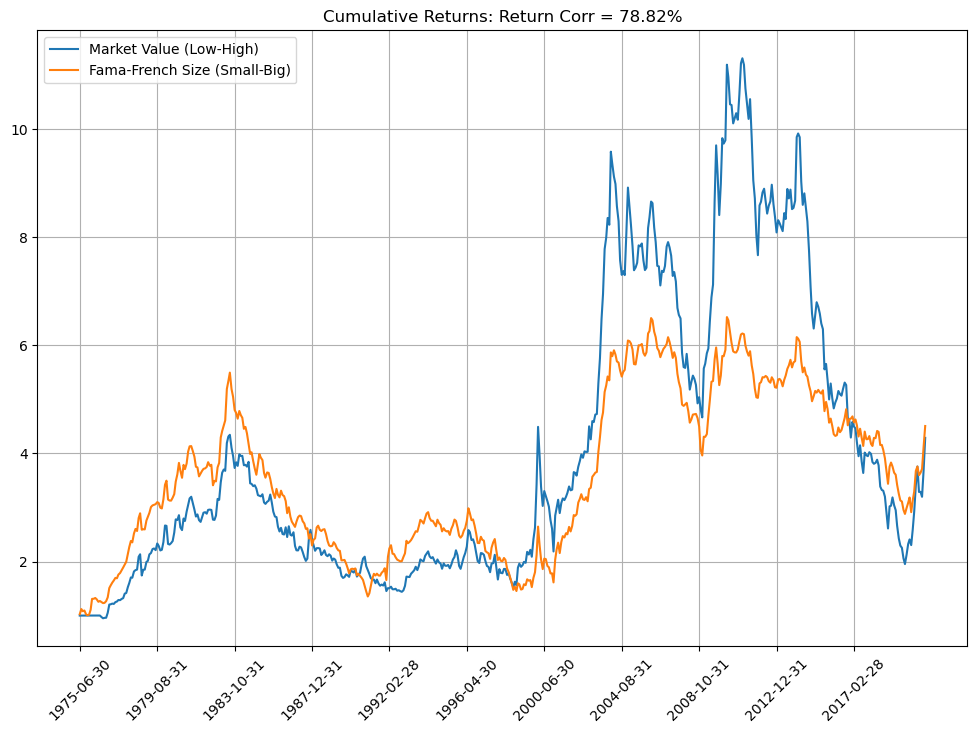

In [9]:
# Select the time to visualize
start = (1975, 6, 1)
end = (2020, 12, 31)
temp = filter_datetime_df(size_portfolio, start, end)
temp_ff = filter_datetime_df(ff_size, start, end)
# Visualization
plt.figure(figsize=(12, 8))
plt.plot(temp.index, (1+ls(temp, 0, -1)).to_numpy().cumprod(), label='Market Value (Low-High)')
plt.plot(temp.index, (1+ls(temp_ff, 0, -1)).to_numpy().cumprod(), label='Fama-French Size (Small-Big)')
corr = np.corrcoef([ls(temp, 0, -1), ls(temp_ff, 0, -1)])[0, 1]
plt.legend()
plt.title(f"Cumulative Returns: Return Corr = {corr:.2%}")
plt.grid()
plt.xticks(temp.index[::50], rotation=45)
plt.show()

# 3 factors

In [10]:
# Return for FF 3 factors
factor3 = pd.read_csv('data//F-F_Research_Data_Factors.CSV', index_col=0, skiprows=3, skipfooter=1, header=0)
factor3 = factor3.iloc[:1179, :]

In [11]:
factor3 = factor3.astype('float')
factor3.index = pd.to_datetime(factor3.index, format='%Y%m')
factor3

,Mkt-RF,SMB,HML,RF
1926-07-01,2.96,-2.56,-2.43,0.22
1926-08-01,2.64,-1.17,3.82,0.25
1926-09-01,0.36,-1.40,0.13,0.23
1926-10-01,-3.24,-0.09,0.70,0.32
1926-11-01,2.53,-0.10,-0.51,0.31
...,...,...,...,...
2024-05-01,4.34,0.78,-1.66,0.44
2024-06-01,2.77,-3.06,-3.31,0.41
2024-07-01,1.24,6.80,5.73,0.45
2024-08-01,1.61,-3.55,-1.13,0.48


# Price Momentum

In [12]:
# Construct price momentum
df_mom = get_momentum(dfs['ret'])
df_mom.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1976-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-02-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-05-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


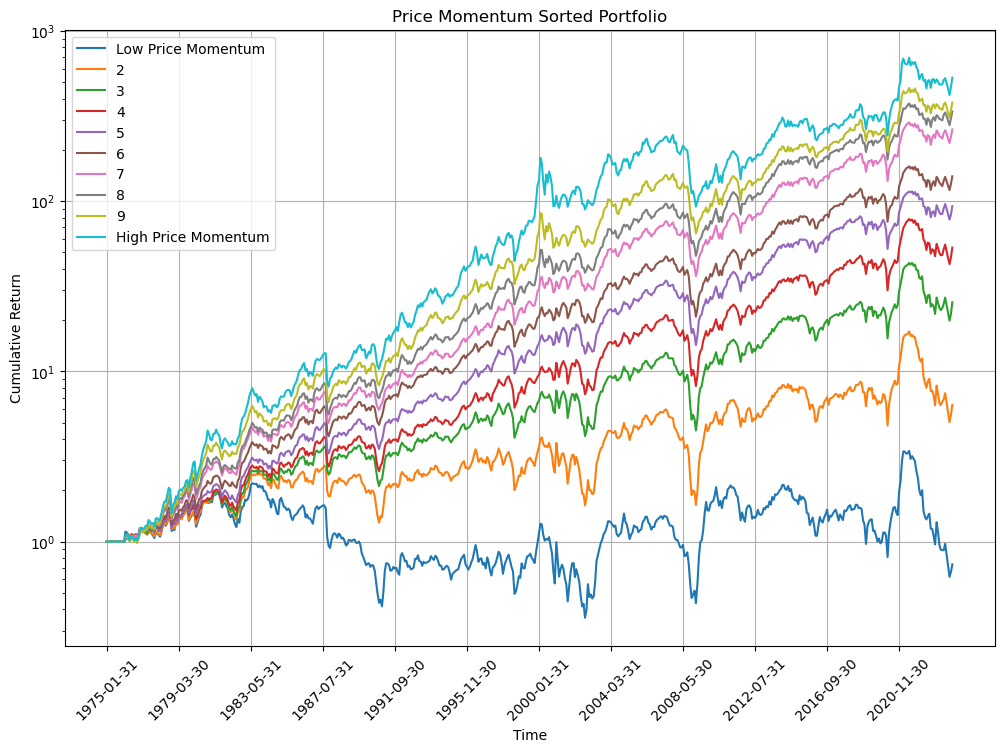

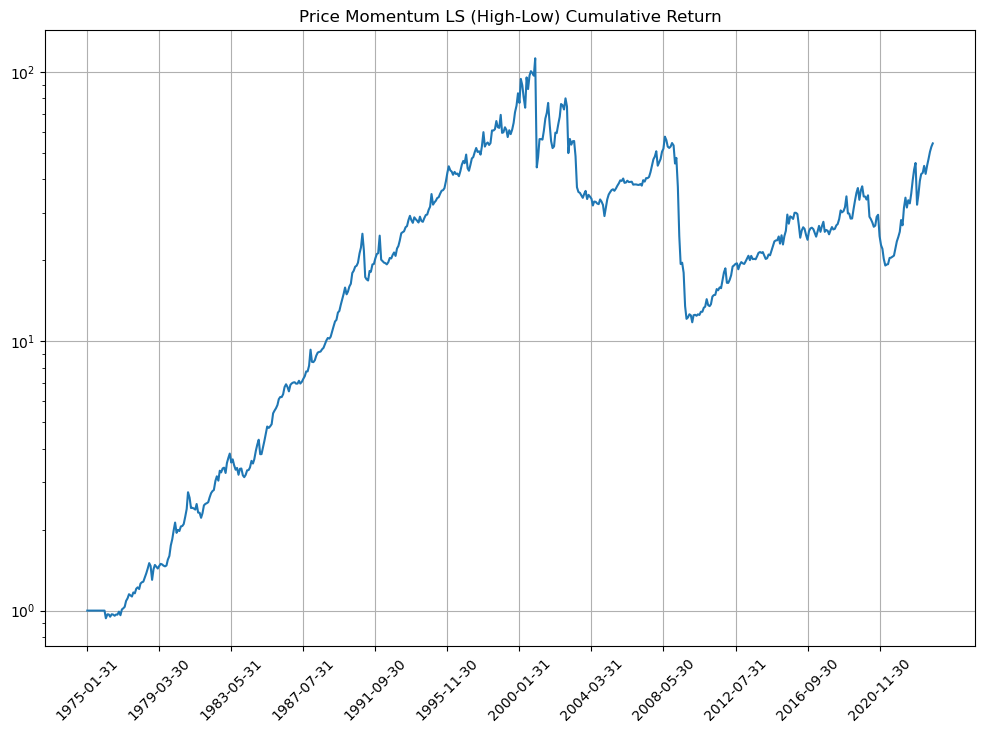

In [13]:
# Construct the quarterly-rebalanced price momentum strategy
price_momentum = forward_fill(df_mom.copy(deep=True), holding_period=3)
# Re-balance each quarter
price_momentum[~idx_Q] = np.nan
mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(df_mom * dfs['idx_vol_threshold'],holding_period=3)
)
# Visualization
plot_group_cum(mom_portfolio, "Price Momentum")
plot_solo_cum(ls(mom_portfolio, -1, 0), "Price Momentum LS (High-Low) Cumulative Return")

# EPS

In [14]:
# Construct earnings per share (EPS)
df_eps = get_eps_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_eps[~idx_Q] = np.nan
df_eps.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,0.08,NaN,NaN,NaN,NaN,NaN,NaN,0.28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,0.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


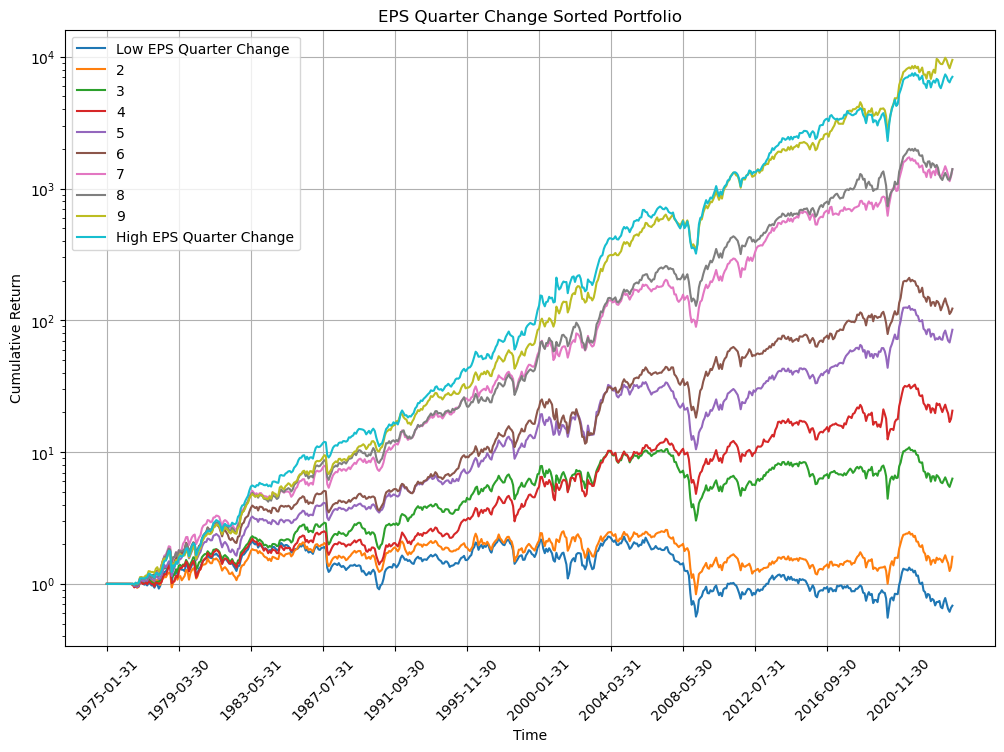

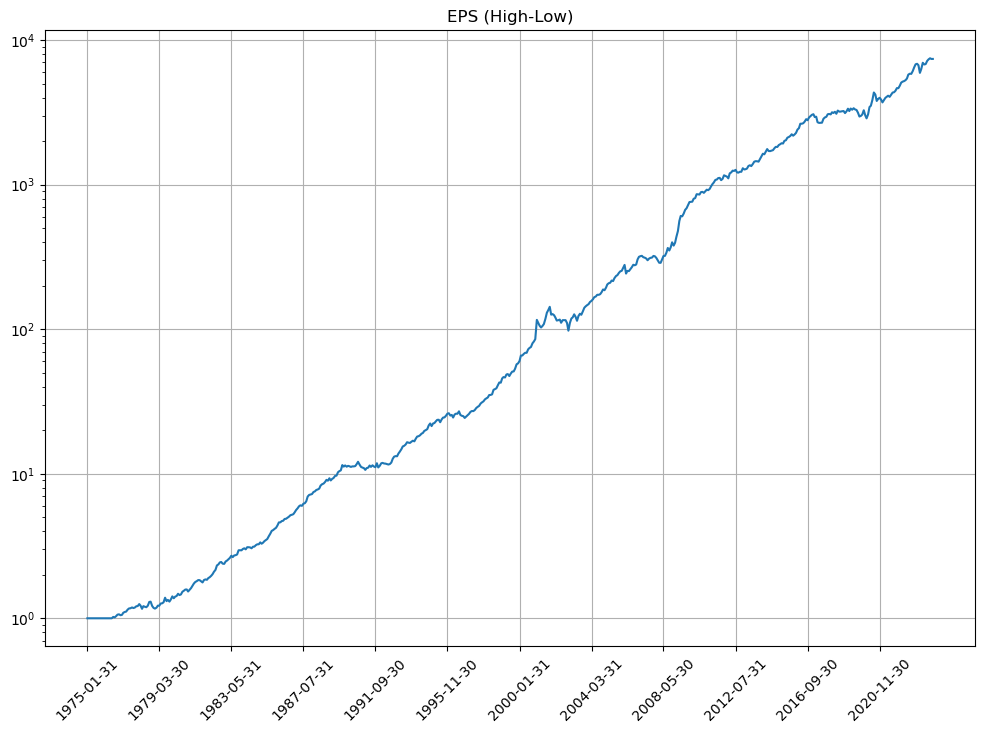

In [15]:
# Get the year over year change
df_eps_pct = df_eps.diff(3) / df_eps.rolling(window=36, min_periods=6).std()
# Compute the portfolio
eps_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(df_eps_pct * dfs['idx_vol_threshold'],holding_period=3)
)
# Visualization
plot_group_cum(eps_pct_portfolio, "EPS Quarter Change")
plot_solo_cum(ls(eps_pct_portfolio, -1, 0), "EPS (High-Low)")

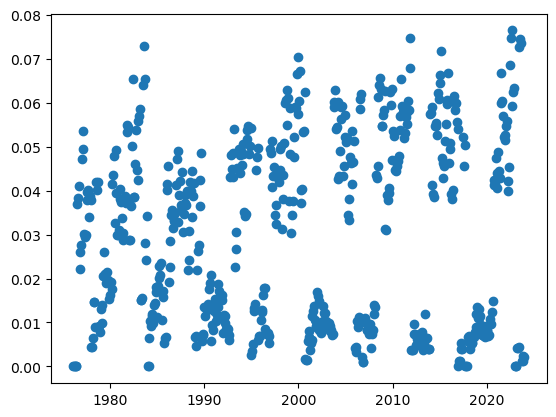

0.030586939292128332


In [16]:
l1 = get_sorted_index(df_eps_pct * dfs['idx_vol_threshold'],holding_period=3)
l2 = get_sorted_index(df_mom * dfs['idx_vol_threshold'],holding_period=3)

overlap_long = count_overlap(l1[0], l2[0])
overlap_short = count_overlap(l1[-1], l2[-1])
overlap = (overlap_long + overlap_short) / 2
plt.scatter(overlap.index, overlap.values)
plt.show()
print(overlap.mean())

In [17]:
y = truncate(ls(eps_pct_portfolio, -1, 0))
dic = {'mom': truncate(ls(mom_portfolio, -1, 0)),
       'smb': truncate(factor3['SMB']),
       'hml': truncate(factor3['HML']),
       'mkt': truncate(factor3['Mkt-RF'])
}
model = lin_reg(y, dic)
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     5.883
Date:                Sat, 07 Dec 2024   Prob (F-statistic):           0.000121
Time:                        14:13:20   Log-Likelihood:                 1092.3
No. Observations:                 570   AIC:                            -2175.
Df Residuals:                     565   BIC:                            -2153.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0176      0.002     11.371      0.000       0.015       0.021
mom           -0.1040      0.022     -4.673      0.000      -0.148      -0.060
smb            0.0005      0.001      0.938      0.349      -0.001       0.002
hml           -0.0003      0.001     -0.515      0.606      -0.001       0.001
mkt           -0.0003      0.000     -0.888      0.375      -0.001       0.000
==============================================================================
Omnibus:                      109.209   Durbin-Watson:                   1.893
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1507.385
Skew:                           0.361   Prob(JB):                         0.00
Kurtosis:                      10.934   Cond. No.                         70.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
matrics(truncate(ls(eps_pct_portfolio, -1, 0)))

Annualized return for factor is 20.63%
t-value for factor is 1.6375


# PM

In [19]:
# Construct the profit margin (PM)
df_pm = get_pm_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_pm[~idx_Q] = np.nan
df_pm.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,0.016822,NaN,NaN,NaN,NaN,NaN,NaN,0.014063,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,0.060591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,0.046715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,0.049132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,0.044743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Construct the profit margin quarterly change
df_pm_pct =  df_pm.diff(3) / df_pm.rolling(window=36, min_periods=6).std()
# df_pm_pct[count_non_cols(df_pm_pct) < 100] = np.nan
pm_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3
        )
)

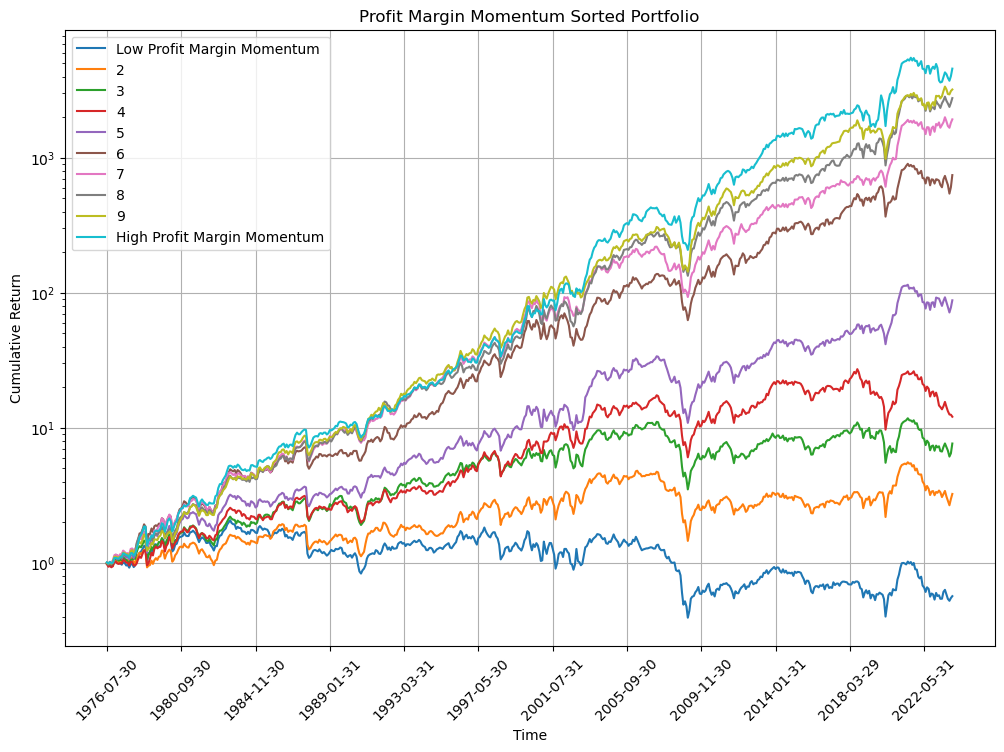

In [21]:
pm_pct_portfolio = pm_pct_portfolio.loc[~(pm_pct_portfolio==0).all(axis=1)]
plot_group_cum(pm_pct_portfolio, "Profit Margin Momentum")

In [22]:
pm_ls = ls(pm_pct_portfolio, -1, 0)
mm_ls = ls(mom_portfolio, -1, 0)
mm_ls = mm_ls[mm_ls.index >= pm_ls.index[0]]
comparison_df = pd.concat(
    [get_aggregated_annual_metrics(pm_ls), get_aggregated_annual_metrics(mm_ls)], axis=1
)
comparison_df.columns = ["PM Momentum", "Price Momentum"]
print(comparison_df.to_latex())

\begin{tabular}{lll}
\toprule
 & PM Momentum & Price Momentum \\
\midrule
Mean & 18.94% & 11.77% \\
Std & 12.43% & 23.75% \\
SR & 1.52 & 0.50 \\
MDD & 25.01% & 89.55% \\
\bottomrule
\end{tabular}


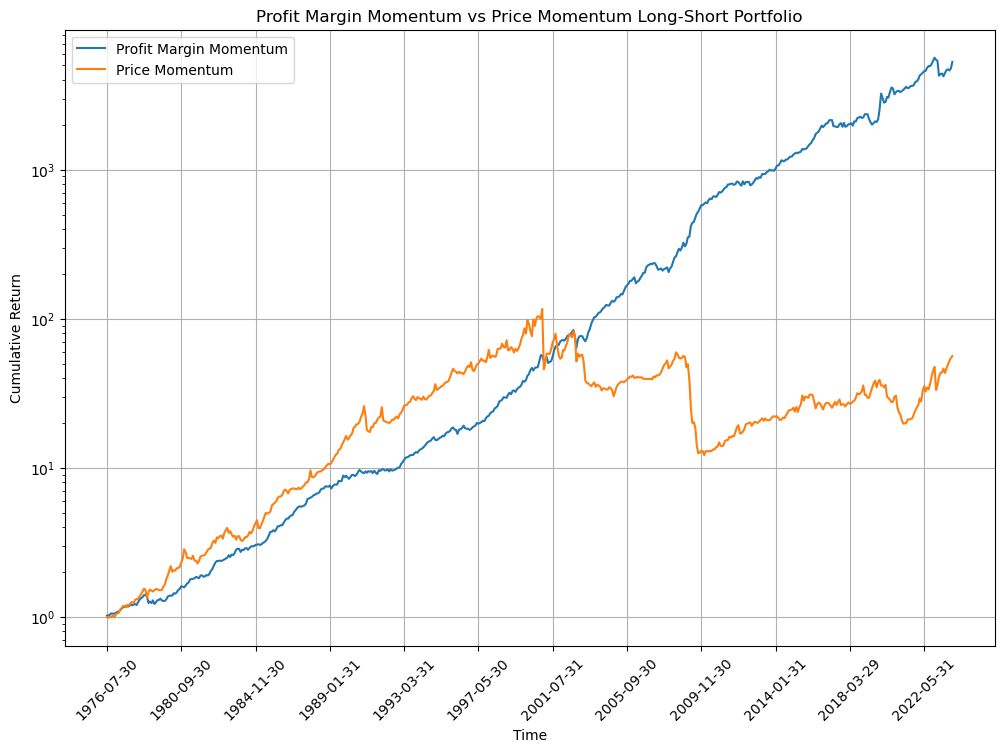

In [23]:
plt.figure(figsize=(12,8))
plt.plot((1+pm_ls).cumprod(), label='Profit Margin Momentum')
plt.plot((1+mm_ls).cumprod(), label='Price Momentum')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.xticks(pm_ls.index[::50], rotation=45)
plt.yscale('log')
plt.title(f"Profit Margin Momentum vs Price Momentum Long-Short Portfolio")
plt.grid()
plt.legend()
plt.show()

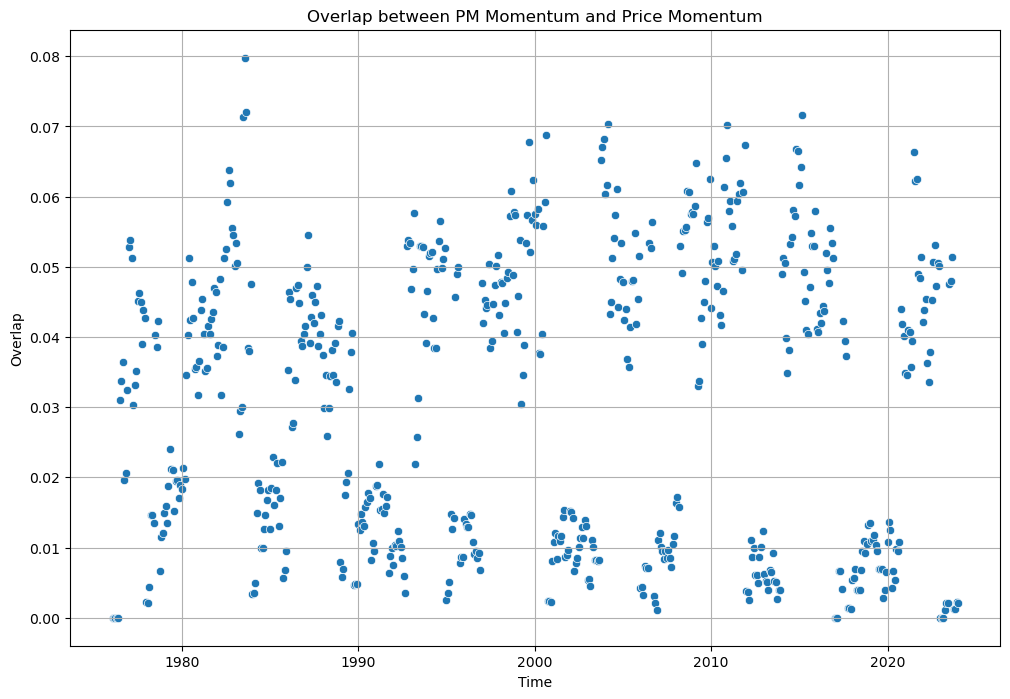

0.030794165776577936


In [24]:
l1 = get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3
        )
l2 = get_sorted_index(df_mom * dfs['idx_vol_threshold'],holding_period=3)

overlap_long = count_overlap(l1[0], l2[0])
overlap_short = count_overlap(l1[-1], l2[-1])
overlap = (overlap_long + overlap_short) / 2
plt.figure(figsize=(12, 8))
sns.scatterplot(overlap)
plt.xlabel('Time')
plt.ylabel('Overlap')
plt.title('Overlap between PM Momentum and Price Momentum')
plt.grid()
plt.show()
print(overlap.mean())

In [25]:
factor3['SMB'].index

DatetimeIndex(['1926-07-01', '1926-08-01', '1926-09-01', '1926-10-01',
               '1926-11-01', '1926-12-01', '1927-01-01', '1927-02-01',
               '1927-03-01', '1927-04-01',
               ...
               '2023-12-01', '2024-01-01', '2024-02-01', '2024-03-01',
               '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01',
               '2024-08-01', '2024-09-01'],
              dtype='datetime64[ns]', length=1179, freq=None)

In [26]:
y = truncate(ls(pm_pct_portfolio, -1, 0))
dic = {'MKT': truncate(factor3['Mkt-RF']),
       'SMB': truncate(factor3['SMB']),
       'HML': truncate(factor3['HML']),
       'MOM': truncate(ls(mom_portfolio, -1, 0))
       
}
model = lin_reg(y, dic)
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     3.785
Date:                Sat, 07 Dec 2024   Prob (F-statistic):            0.00477
Time:                        14:13:26   Log-Likelihood:                 1096.0
No. Observations:                 570   AIC:                            -2182.
Df Residuals:                     565   BIC:                            -2160.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0153      0.002      9.927      0.000       0.012       0.018
MKT           -0.0003      0.000     -0.727      0.467      -0.001       0.000
SMB            0.0005      0.001      0.877      0.381      -0.001       0.001
HML            0.0018      0.001      3.586      0.000       0.001       0.003
MOM            0.0212      0.022      0.959      0.338      -0.022       0.065
==============================================================================
Omnibus:                      118.645   Durbin-Watson:                   1.836
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1938.986
Skew:                           0.386   Prob(JB):                         0.00
Kurtosis:                      12.003   Cond. No.                         70.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
print(get_formatted_spanning_test_results(model.fit()))

\begin{tabular}{lccccc}
\toprule
 & const & MKT & SMB & HML & MOM \\
\midrule
Coefficient & 0.015 & -0.000 & 0.000 & 0.002 & 0.021 \\
t-statistic & (9.93) & (-0.73) & (0.88) & (3.59) & (0.96) \\
\bottomrule
\end{tabular}


In [28]:
y = truncate(ls(mom_portfolio, -1, 0))

dic = {'MKT': truncate(factor3['Mkt-RF']),
       'SMB': truncate(factor3['SMB']),
       'HML': truncate(factor3['HML']),
       'PMM': truncate(ls(pm_pct_portfolio, -1, 0))
       
}
model = lin_reg(y, dic)
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     5.326
Date:                Sat, 07 Dec 2024   Prob (F-statistic):           0.000324
Time:                        14:13:26   Log-Likelihood:                 729.78
No. Observations:                 570   AIC:                            -1450.
Df Residuals:                     565   BIC:                            -1428.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0108      0.003      3.460      0.001       0.005       0.017
MKT           -0.0017      0.001     -2.584      0.010      -0.003      -0.000
SMB           -0.0019      0.001     -1.861      0.063      -0.004       0.000
HML           -0.0035      0.001     -3.665      0.000      -0.005      -0.002
PMM            0.0766      0.080      0.959      0.338      -0.080       0.234
==============================================================================
Omnibus:                      314.419   Durbin-Watson:                   2.046
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5615.412
Skew:                          -2.022   Prob(JB):                         0.00
Kurtosis:                      17.835   Cond. No.                         134.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
print(get_formatted_spanning_test_results(model.fit()))

\begin{tabular}{lccccc}
\toprule
 & const & MKT & SMB & HML & PMM \\
\midrule
Coefficient & 0.011 & -0.002 & -0.002 & -0.004 & 0.077 \\
t-statistic & (3.46) & (-2.58) & (-1.86) & (-3.67) & (0.96) \\
\bottomrule
\end{tabular}


In [30]:
matrics(truncate(ls(pm_pct_portfolio, -1, 0)))

Annualized return for factor is 19.78%
t-value for factor is 1.5912


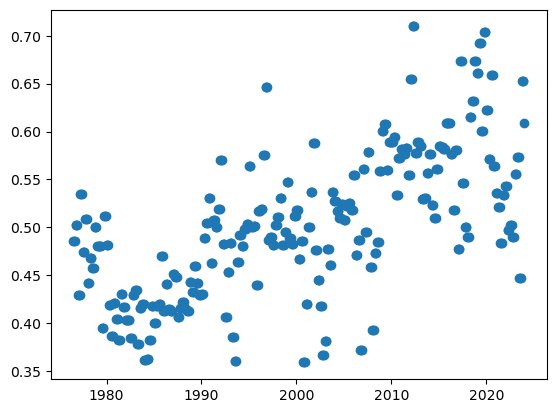

0.5010296392274022


In [31]:
l1 = get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3
        )
l2 = get_sorted_index(df_eps_pct * dfs['idx_vol_threshold'],holding_period=3)

overlap_long = count_overlap(l1[0], l2[0])
overlap_short = count_overlap(l1[-1], l2[-1])
overlap = (overlap_long + overlap_short) / 2
plt.scatter(overlap.index, overlap.values)
plt.show()
print(overlap.mean())

# Double Sort Protfolios based on Price Momentum, EPS, and Profit Margin

In [334]:
# def sr(date):
#     pm_sr = []
#     con_sr = []
#     for i in range(35):
#         pm_benchmark_index_temp = get_sorted_index(
#             df_pm_pct * dfs['idx_vol_threshold'],
#             holding_period=3, quantiles = np.array([0.05 + i * 0.01,0.95-i*0.01])
#             )
#         pm_benchmark_portfolio_temp = get_sorted_portfolio(
#             dfs['ret'], pm_benchmark_index_temp
#         )
#         pm_sr.append((get_aggregated_annual_metrics(ls(pm_benchmark_portfolio_temp[pm_benchmark_portfolio_temp.index >= date], -1, 0))['SR'],0.05 + i * 0.01))
#     
#     for i in range(15):
#         for j in range(15):
#             pm_index_temp = get_sorted_index(
#                 df_pm_pct * dfs['idx_vol_threshold'],
#                 holding_period=3, quantiles = np.array([0.15 + i * 0.02,0.85-i*0.02])
#                 )
#             mom_index_temp = get_sorted_index(
#                 df_mom * dfs['idx_vol_threshold'],
#                 holding_period=3, quantiles = np.array([0.15 + j * 0.02,0.85-j*0.02])
#                 )
#             condition_pm_mom_temp = []
#             for k in range(len(pm_index_temp)):
#                 condition_pm_mom_temp.append(pm_index_temp[k] * mom_index_temp[2])
#             con_pm_mom_portfolio_temp = get_sorted_portfolio(
#                 dfs['ret'], condition_pm_mom_temp
#             )
#             con_sr.append((get_aggregated_annual_metrics(ls(con_pm_mom_portfolio_temp[con_pm_mom_portfolio_temp.index >= date], -1, 0))['SR'],0.15 + i * 0.02, 0.15 + j * 0.02))
#     return pm_sr, con_sr

In [450]:
pm_index = get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.25,0.75])
        )

eps_index = get_sorted_index(
        df_eps_pct * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.2,0.8])
        )

mom_index = get_sorted_index(
        df_mom * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.2,0.8])
        )

In [457]:
condition_pm_eps = []
for i in range(len(eps_index)):
    condition_pm_eps.append(eps_index[i] * pm_index[i])
condition_mom_eps = []
for i in range(len(eps_index)):
    condition_mom_eps.append(eps_index[i] * mom_index[i])
condition_pm_mom = []
for i in range(len(pm_index)):
    condition_pm_mom.append(pm_index[i] * mom_index[2])
    
condition_pm_mom_low = []
for i in range(len(pm_index)):
    condition_pm_mom_low.append(pm_index[i] * mom_index[0])

In [458]:
eps_benchmark_index = get_sorted_index(
        df_eps_pct * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.1,0.9])
        )

pm_benchmark_index = get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.1,0.9])
        )

mom_benchmark_index = get_sorted_index(
        df_mom * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.1,0.9])
        )

eps_benchmark_portfolio = get_sorted_portfolio(
    dfs['ret'], eps_benchmark_index
)

pm_benchmark_portfolio = get_sorted_portfolio(
    dfs['ret'], pm_benchmark_index
)

mom_benchmark_portfolio = get_sorted_portfolio(
    dfs['ret'], mom_benchmark_index
)

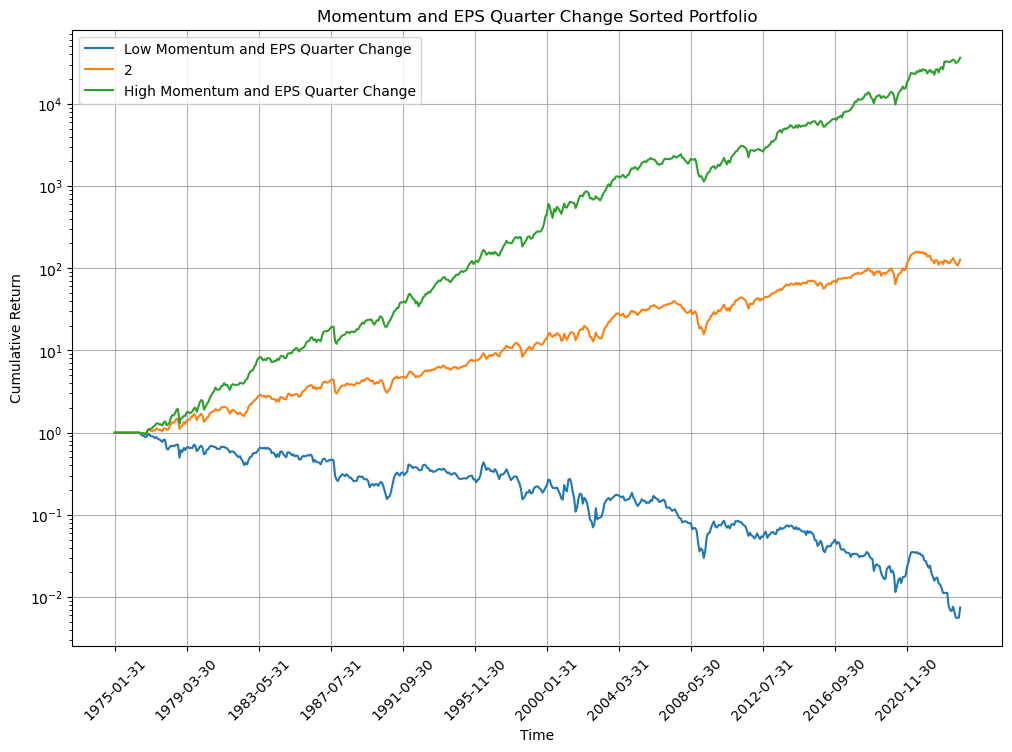

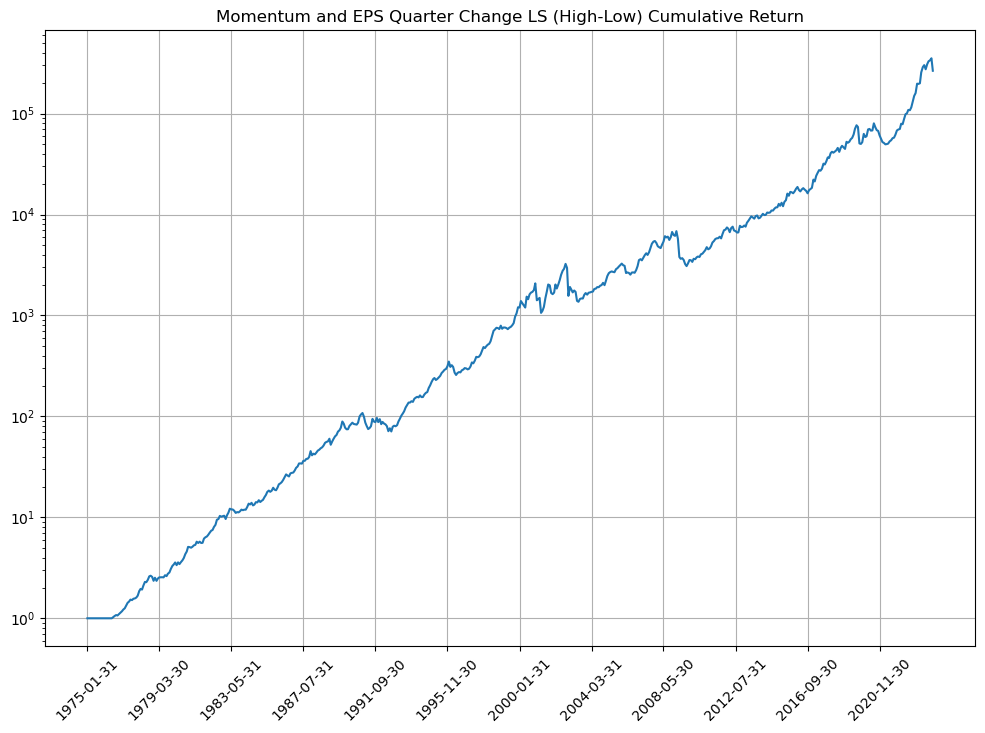

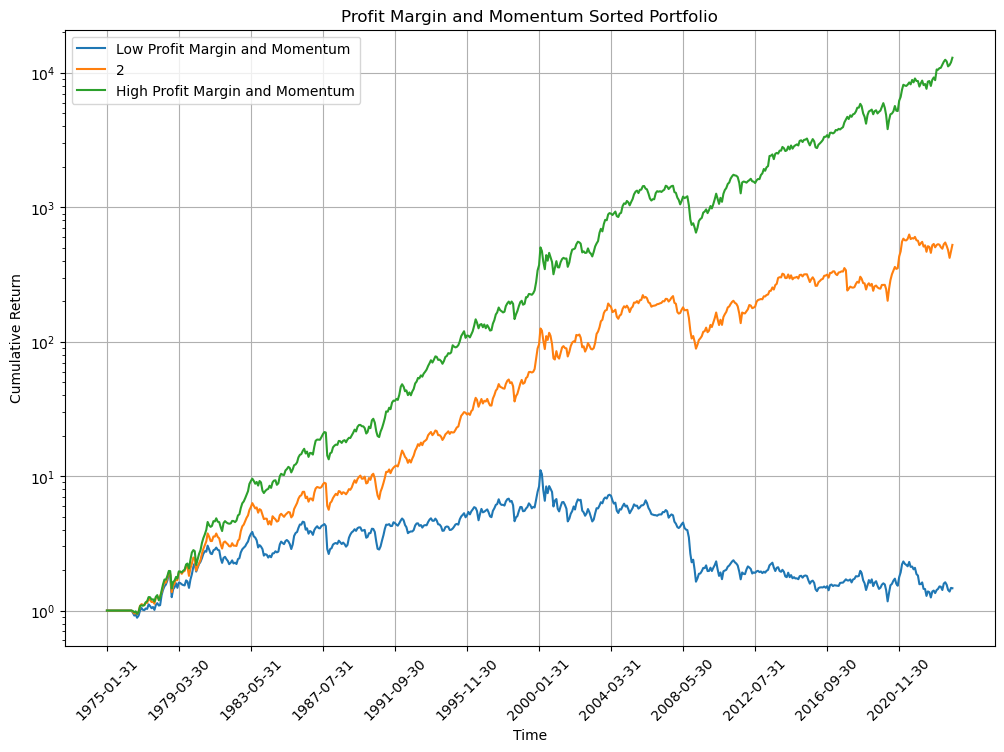

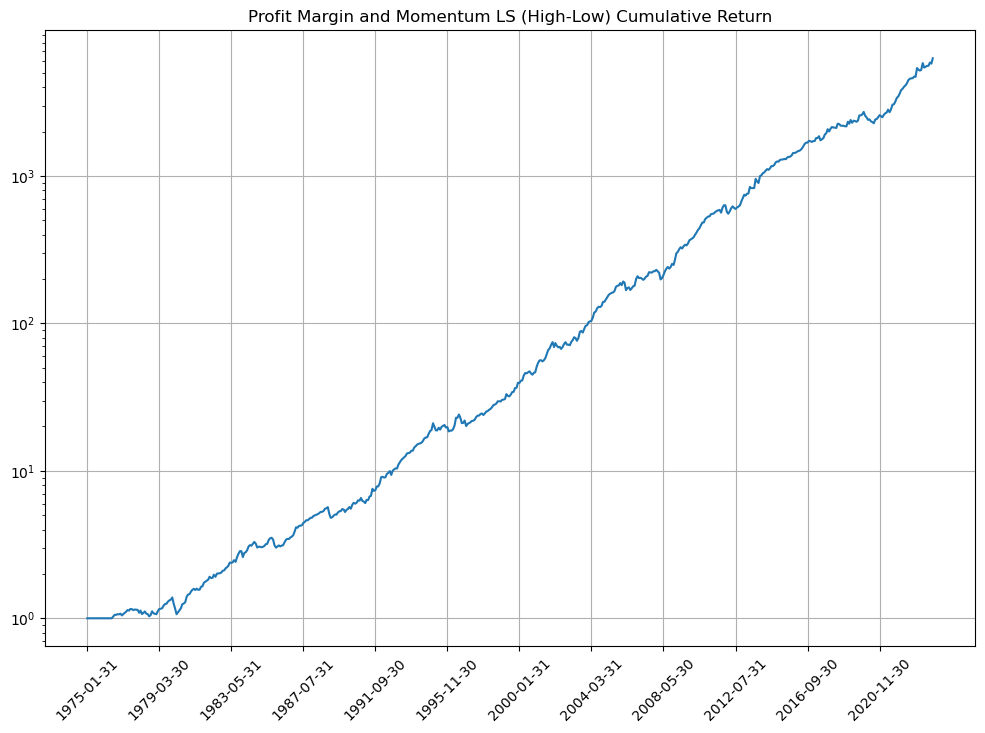

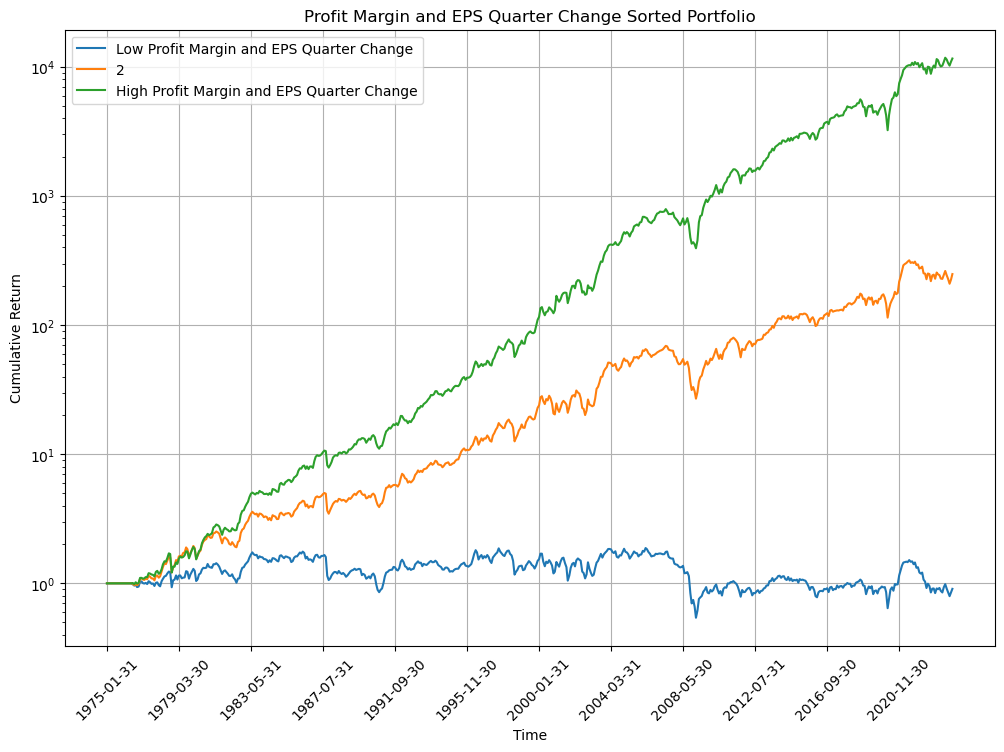

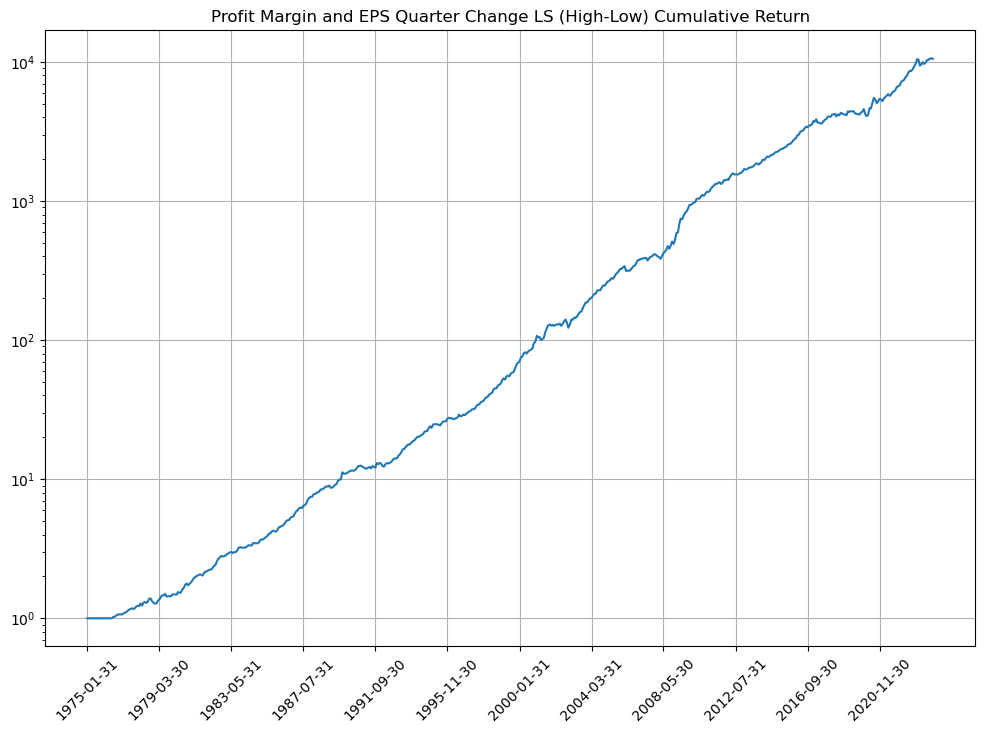

In [459]:
condition_mom_eps_portfolio = get_sorted_portfolio(
    dfs['ret'], condition_mom_eps
)
plot_group_cum(condition_mom_eps_portfolio, "Momentum and EPS Quarter Change")
plot_solo_cum(ls(condition_mom_eps_portfolio, -1, 0),
              "Momentum and EPS Quarter Change LS (High-Low) Cumulative Return")

condition_pm_mom_portfolio = get_sorted_portfolio(
    dfs['ret'], condition_pm_mom
)
plot_group_cum(condition_pm_mom_portfolio, "Profit Margin and Momentum")
plot_solo_cum(ls(condition_pm_mom_portfolio, -1, 0),
              "Profit Margin and Momentum LS (High-Low) Cumulative Return")

condition_pm_eps_portfolio = get_sorted_portfolio(
    dfs['ret'], condition_pm_eps
)
plot_group_cum(condition_pm_eps_portfolio, "Profit Margin and EPS Quarter Change")
plot_solo_cum(ls(condition_pm_eps_portfolio, -1, 0),
              "Profit Margin and EPS Quarter Change LS (High-Low) Cumulative Return")

condition_pm_mom_low_portfolio = get_sorted_portfolio(
    dfs['ret'], condition_pm_mom_low
)

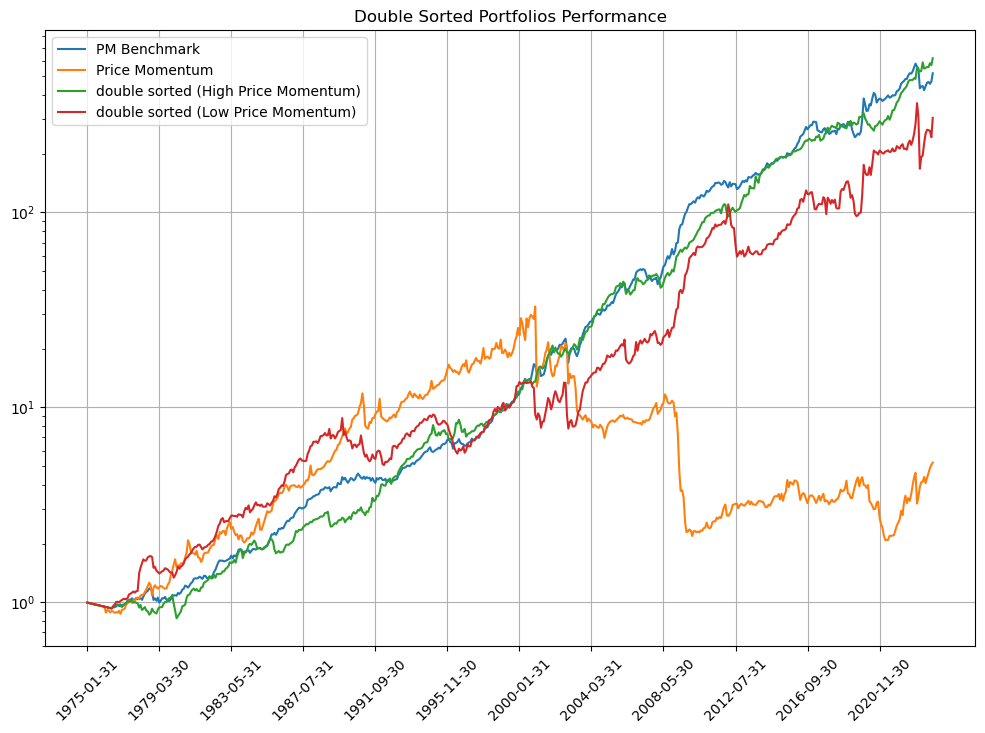

Mean    13.56%
Std     12.27%
SR        1.11
MDD     26.89%
dtype: object
Mean    13.90%
Std     12.02%
SR        1.16
MDD     24.06%
dtype: object
Mean    14.20%
Std     21.90%
SR        0.65
MDD     53.90%
dtype: object
Mean    24.23%
Std     24.90%
SR        0.97
MDD     59.57%
dtype: object


In [500]:
plt.figure(figsize=(12,8))
plt.plot((1+ls(pm_benchmark_portfolio, -1,0)- 0.002 * 2).cumprod(), label='PM Benchmark')
plt.plot((1+ls(mom_benchmark_portfolio, -1, 0)- 0.002 * 2).cumprod(), label='Price Momentum')
plt.plot((1+ls(condition_pm_mom_portfolio,-1,0)- 0.002 * 2).cumprod(), label='double sorted (High Price Momentum)')
plt.plot((1+ls(condition_pm_mom_low_portfolio, -1, 0)- 0.002 * 2).cumprod(), label='double sorted (Low Price Momentum)')
plt.xticks(ls(eps_pct_portfolio, -1, 0).index[::50], rotation=45)
plt.legend()
plt.yscale('log')
plt.title('Double Sorted Portfolios Performance')
plt.grid()
plt.show()

print(get_aggregated_annual_metrics(ls(pm_benchmark_portfolio, -1,0)- 0.002 * 2))
print(get_aggregated_annual_metrics(ls(condition_pm_mom_portfolio,-1,0)- 0.002 * 2))
print(get_aggregated_annual_metrics(ls(condition_pm_mom_low_portfolio, -1, 0)- 0.002 * 2))
print(get_aggregated_annual_metrics(ls(condition_mom_eps_portfolio, -1, 0)- 0.002 * 2))

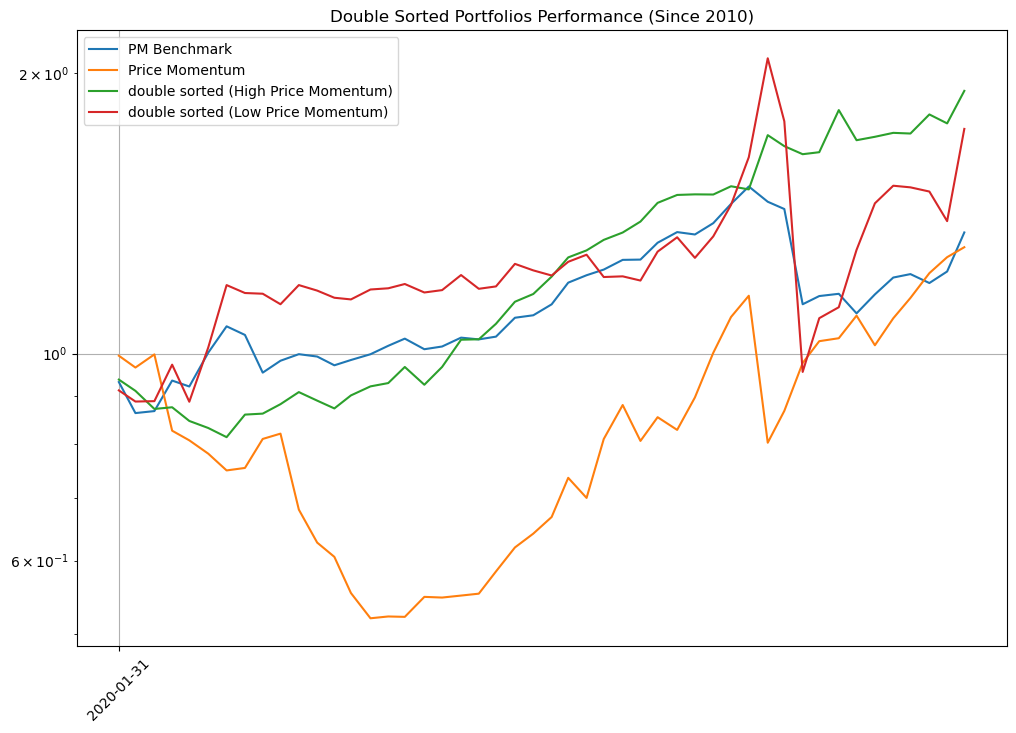

Mean     9.05%
Std     17.28%
SR        0.52
MDD     26.89%
dtype: object
Mean    17.29%
Std     14.23%
SR        1.22
MDD     13.25%
dtype: object
Mean    21.83%
Std     37.43%
SR        0.58
MDD     53.90%
dtype: object
Mean    36.78%
Std     32.41%
SR        1.13
MDD     40.10%
dtype: object


In [501]:
cutoff_date = '2020-1-01'
plt.figure(figsize=(12,8))
plt.plot((1+ls(pm_benchmark_portfolio[pm_benchmark_portfolio.index >= cutoff_date], -1,0)- 0.002 * 2).cumprod(), label='PM Benchmark')
plt.plot((1+ls(mom_benchmark_portfolio[pm_benchmark_portfolio.index >= cutoff_date], -1, 0)- 0.002 * 2).cumprod(), label='Price Momentum')
plt.plot((1+ls(condition_pm_mom_portfolio[pm_benchmark_portfolio.index >= cutoff_date],-1,0)- 0.002 * 2).cumprod(), label='double sorted (High Price Momentum)')
plt.plot((1+ls(condition_pm_mom_low_portfolio[pm_benchmark_portfolio.index >= cutoff_date],-1,0)- 0.002 * 2).cumprod(), label='double sorted (Low Price Momentum)')
plt.xticks(ls(eps_pct_portfolio[pm_benchmark_portfolio.index >= cutoff_date], -1, 0).index[::50], rotation=45)
plt.legend()
plt.yscale('log')
plt.title('Double Sorted Portfolios Performance (Since 2010)')
plt.grid()
plt.show()

print(get_aggregated_annual_metrics(ls(pm_benchmark_portfolio[pm_benchmark_portfolio.index >= cutoff_date], -1,0)- 0.002 * 2))
print(get_aggregated_annual_metrics(ls(condition_pm_mom_portfolio[pm_benchmark_portfolio.index >= cutoff_date],-1,0)- 0.002 * 2))
print(get_aggregated_annual_metrics(ls(condition_pm_mom_low_portfolio[pm_benchmark_portfolio.index >= cutoff_date],-1,0)- 0.002 * 2))
print(get_aggregated_annual_metrics(ls(condition_mom_eps_portfolio[pm_benchmark_portfolio.index >= cutoff_date], -1, 0)- 0.002 * 2))

In [469]:
pd.concat(
    [get_aggregated_annual_metrics(ls(pm_benchmark_portfolio, -1,0)), get_aggregated_annual_metrics(ls(condition_pm_mom_portfolio,-1,0)),get_aggregated_annual_metrics(ls(condition_pm_mom_low_portfolio, -1, 0))], axis=1
).to_latex()

'\\begin{tabular}{llll}\n\\toprule\n & 0 & 1 & 2 \\\\\n\\midrule\nMean & 18.36% & 18.70% & 19.00% \\\\\nStd & 12.27% & 12.02% & 21.90% \\\\\nSR & 1.50 & 1.56 & 0.87 \\\\\nMDD & 25.01% & 23.05% & 53.34% \\\\\n\\bottomrule\n\\end{tabular}\n'

# Frequency

In [37]:
# Find all the column values that has valid quarter values for over 80% of the companies
cols_valid = comp_fundq.columns[comp_fundq.isna().mean() < 0.2]
cols_valid

Index(['gvkey', 'date', 'fyearq', 'fqtr', 'fyr', 'indfmt', 'consol', 'popsrc',
       'datafmt', 'tic', 'cusip', 'conm', 'ajexq', 'ajpq', 'curcdq',
       'datacqtr', 'datafqtr', 'finalq', 'rp', 'srcq', 'updq', 'csh12q',
       'cshoq', 'cshprq', 'cstkeq', 'dvpq', 'epspiq', 'epspxq', 'ibadjq',
       'ibcomq', 'ibq', 'niq', 'piq', 'saleq', 'txtq', 'xidoq', 'iid', 'exchg',
       'cik', 'costat', 'fic', 'cshtrq', 'dvpspq', 'dvpsxq', 'prccq', 'prchq',
       'prclq', 'adjex'],
      dtype='object')

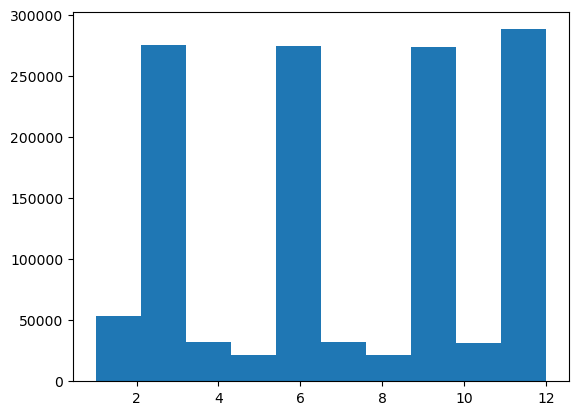

In [38]:
freq_df = comp_fundq[~comp_fundq['dvpsxq'].isna()][['date', 'cusip', 'dvpsxq']]
plt.hist(freq_df['date'].dt.month)
plt.show()

# DVX

In [39]:
# Construct the divident yield (DVX)
df_dvx = get_dvx_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_dvx[~idx_Q] = np.nan
df_dvx.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000022,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


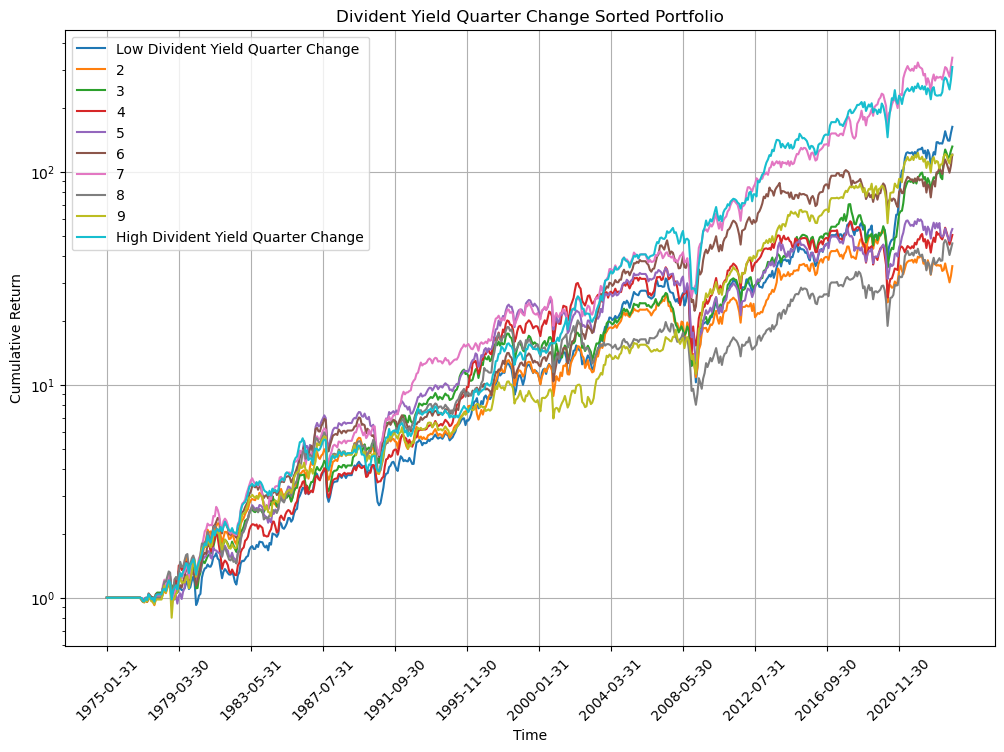

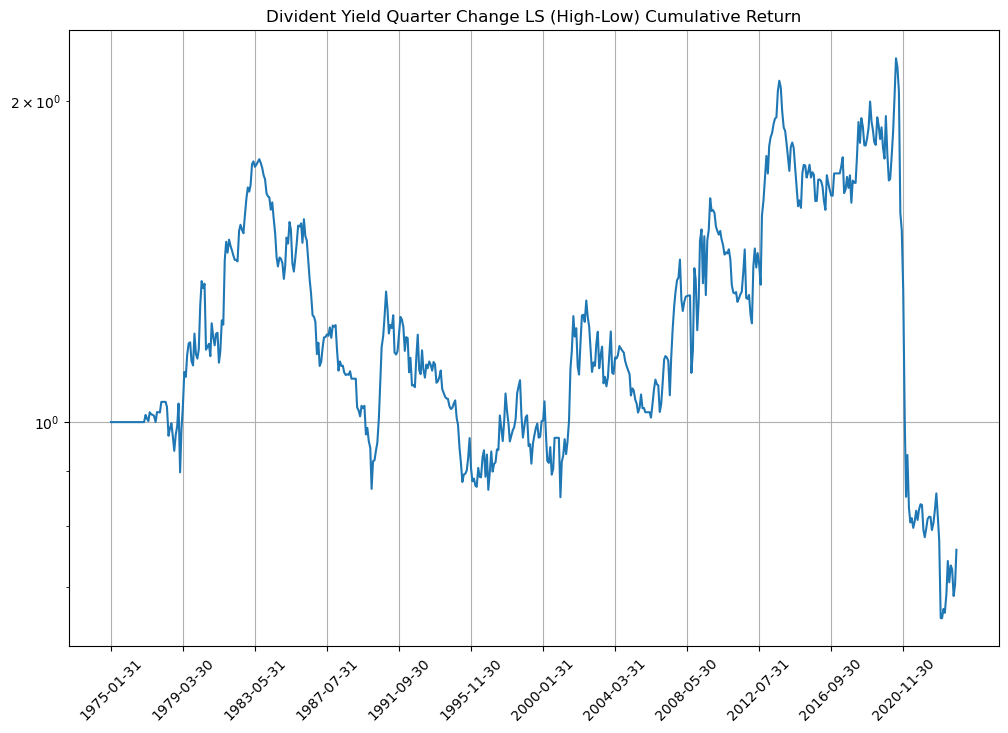

In [40]:
# Construct the divident yield quarterly change
df_dvx_pct =  df_dvx.diff(3) / df_dvx.rolling(window=36, min_periods=8).std()
dvx_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_dvx_pct * dfs['idx_vol_threshold'],
        holding_period=3,
        quantiles=np.linspace(.1, 1, 9, endpoint=False)
        )
)
plot_group_cum(dvx_pct_portfolio, "Divident Yield Quarter Change")
plot_solo_cum(ls(dvx_pct_portfolio, -1, 0), "Divident Yield Quarter Change LS (High-Low) Cumulative Return")

# CR

In [41]:
# Construct the current ratio (CR)
df_cr = get_cr_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_cr[~idx_Q] = np.nan
df_cr.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,2.629499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,2.472467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


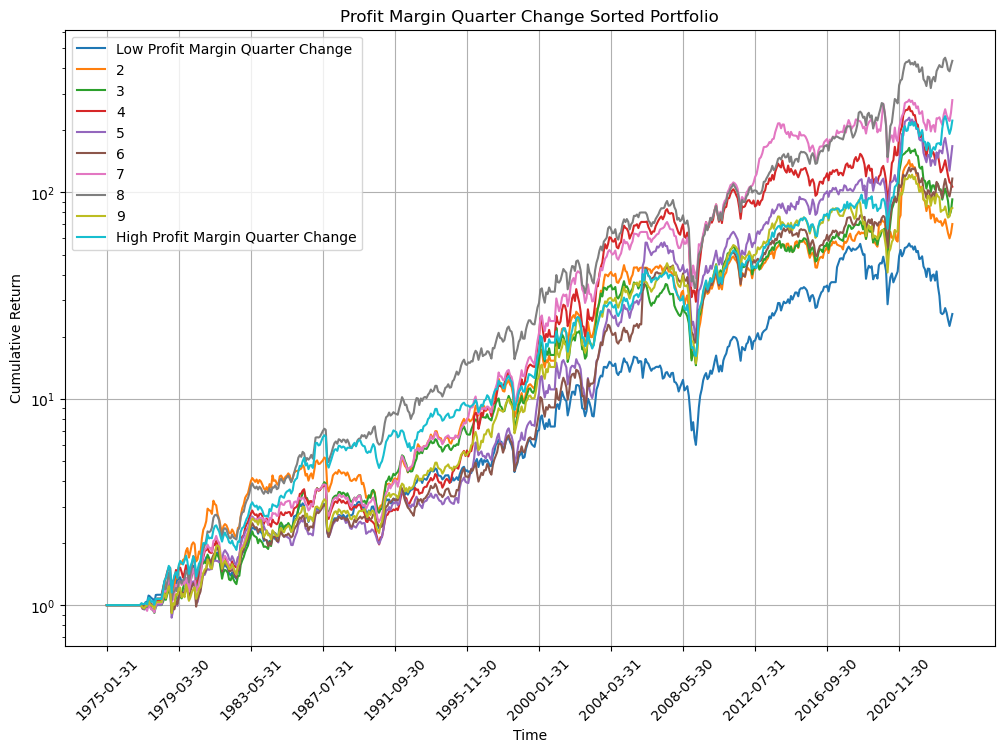

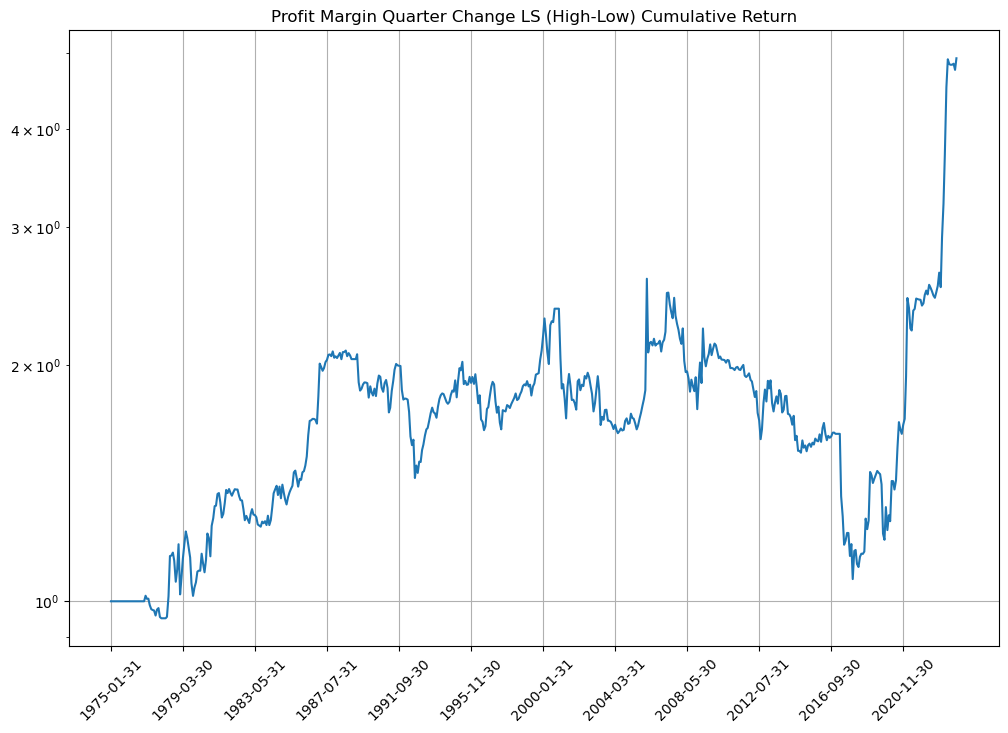

In [42]:
# Construct the current ratio quarterly change
df_cr_pct =  df_cr.diff(3) / df_cr.rolling(window=36, min_periods=8).std()
cr_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_cr_pct * dfs['idx_vol_threshold'],
        holding_period=3,
        quantiles=np.linspace(.1, 1, 9, endpoint=False)
        )
)
plot_group_cum(cr_pct_portfolio, "Profit Margin Quarter Change")
plot_solo_cum(ls(cr_pct_portfolio, -1, 0), "Profit Margin Quarter Change LS (High-Low) Cumulative Return")

In [43]:
y = truncate(ls(cr_pct_portfolio, -1, 0))
dic = {'mom': truncate(ls(mom_portfolio, -1, 0)),
       'smb': truncate(factor3['SMB']),
       'hml': truncate(factor3['HML']),
       'mkt': truncate(factor3['Mkt-RF'])
}
model = lin_reg(y, dic)
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     6.610
Date:                Sat, 07 Dec 2024   Prob (F-statistic):           3.34e-05
Time:                        14:13:43   Log-Likelihood:                 973.60
No. Observations:                 564   AIC:                            -1937.
Df Residuals:                     559   BIC:                            -1916.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0029      0.002      1.517      0.130      -0.001       0.007
mom            0.1002      0.027      3.720      0.000       0.047       0.153
smb            0.0017      0.001      2.670      0.008       0.000       0.003
hml           -0.0010      0.001     -1.635      0.103      -0.002       0.000
mkt           -0.0002      0.000     -0.511      0.610      -0.001       0.001
==============================================================================
Omnibus:                      295.757   Durbin-Watson:                   1.940
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5812.860
Skew:                           1.847   Prob(JB):                         0.00
Kurtosis:                      18.288   Cond. No.                         70.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [44]:
matrics(truncate(ls(cr_pct_portfolio, -1, 0)))

Annualized return for factor is 3.45%
t-value for factor is 0.2257


# BM

In [45]:
# Construct the book to market ratio (BM)
df_bm = get_bm_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_bm[~idx_Q] = np.nan
df_bm.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


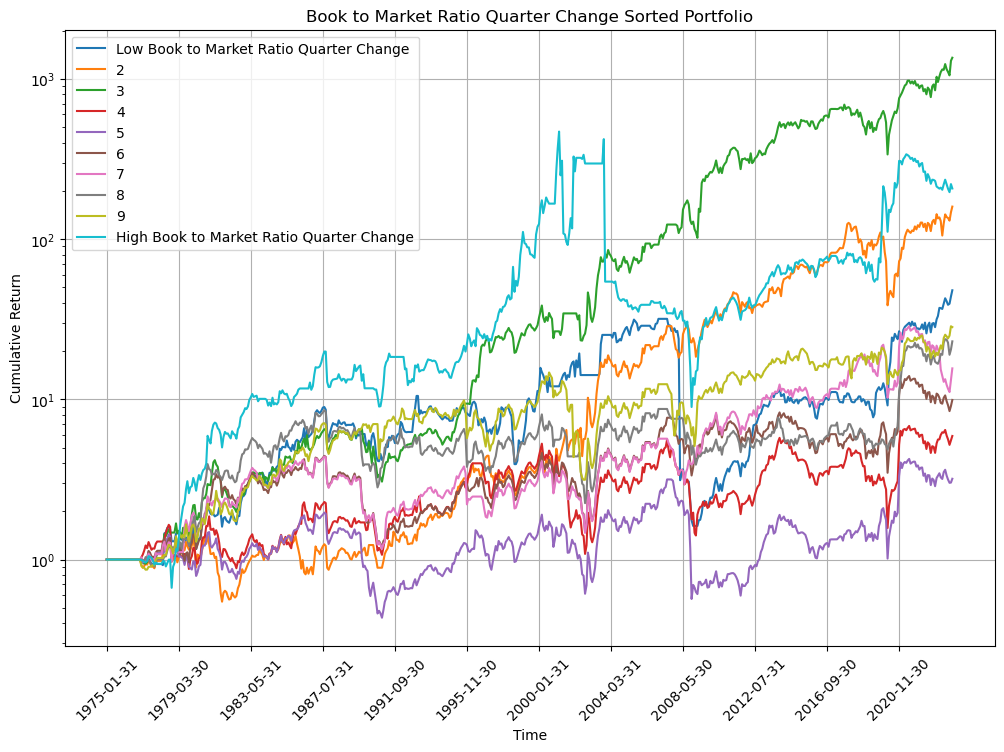

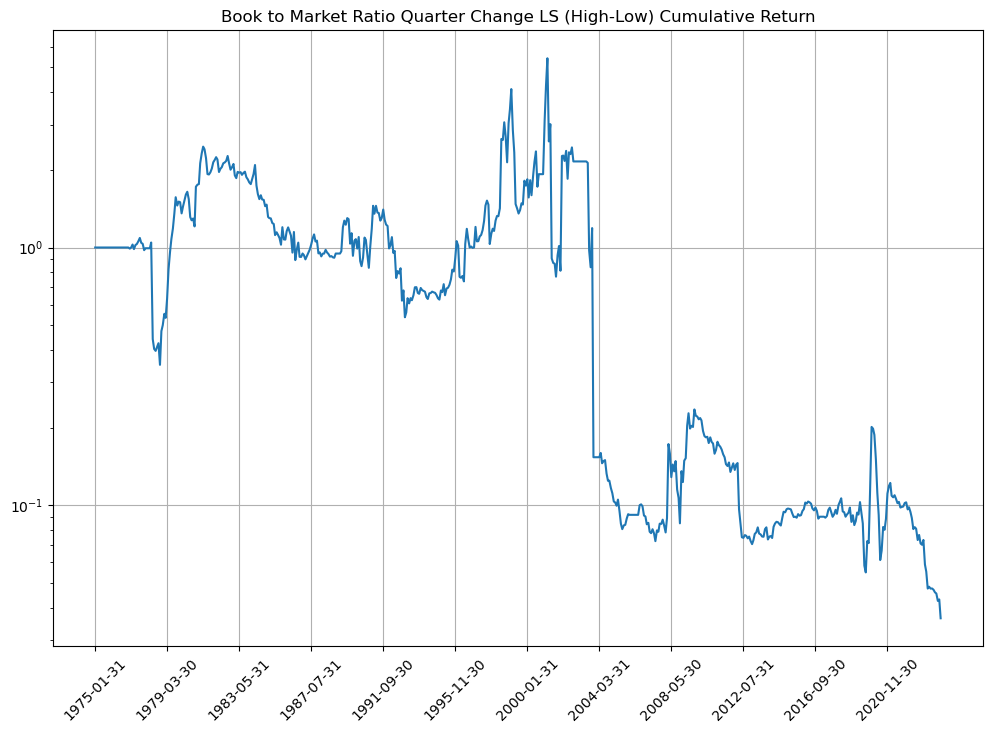

In [46]:
# Construct the book to market ratio quarterly change
df_bm_pct =  df_bm.diff(3) / df_bm.rolling(window=36, min_periods=8).std()
bm_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_bm_pct * dfs['idx_vol_threshold'],
        holding_period=3,
        quantiles=np.linspace(.1, 1, 9, endpoint=False)
        )
)
plot_group_cum(bm_pct_portfolio, "Book to Market Ratio Quarter Change")
plot_solo_cum(ls(bm_pct_portfolio, -1, 0), "Book to Market Ratio Quarter Change LS (High-Low) Cumulative Return")

# EV / EBITDA

In [47]:
# Construct the ev / ebitda (e2e)
df_e2e = get_e2e_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_e2e[~idx_Q] = np.nan
df_e2e.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,0.728119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,0.728119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


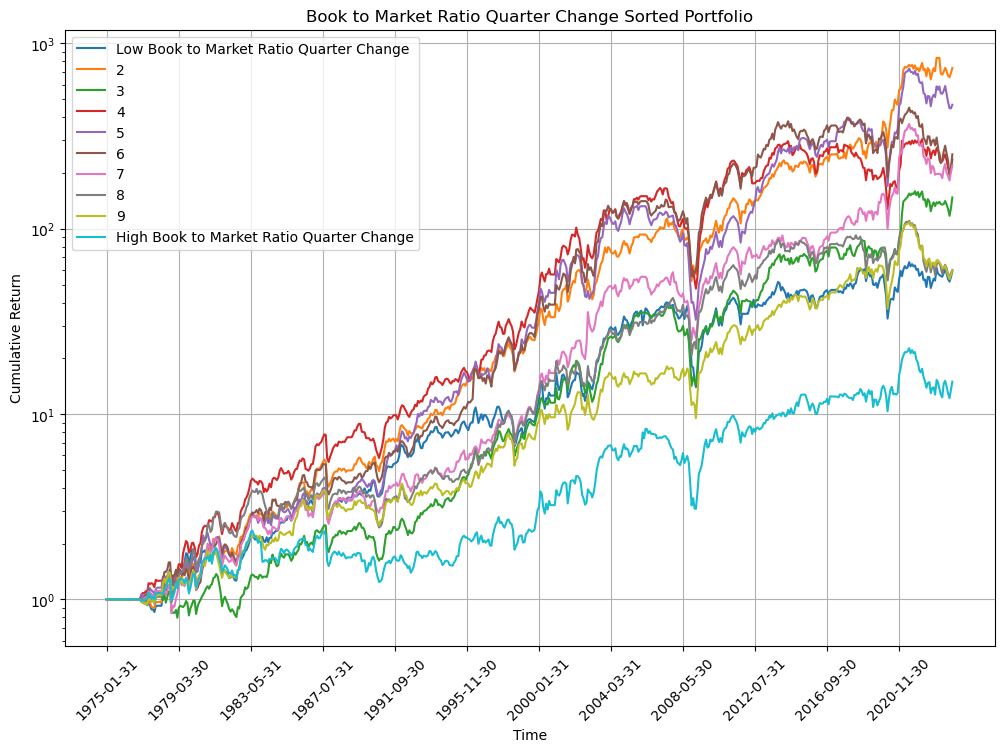

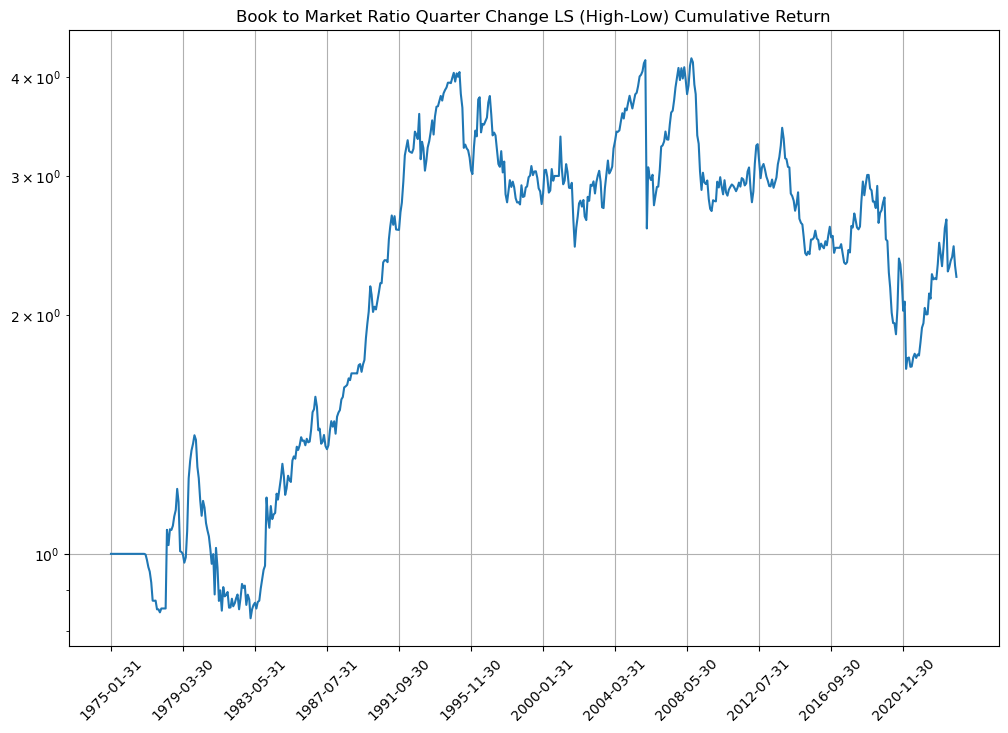

In [48]:
# Construct the ev / ebitda quarterly change
df_e2e_pct =  df_e2e.diff(3) / df_e2e.rolling(window=36, min_periods=8).std()
e2e_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_e2e_pct * dfs['idx_vol_threshold'],
        holding_period=3,
        quantiles=np.linspace(.1, 1, 9, endpoint=False)
        )
)
plot_group_cum(e2e_pct_portfolio, "Book to Market Ratio Quarter Change")
plot_solo_cum(ls(e2e_pct_portfolio, 0, -1), "Book to Market Ratio Quarter Change LS (High-Low) Cumulative Return")

# SM

In [49]:
# Construct the sale / total market value (SM)
df_sm = get_sm_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_sm[~idx_Q] = np.nan
df_sm.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,1.799713,NaN,NaN,NaN,NaN,NaN,NaN,2.171777,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,2.401031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,1.566619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,1.343756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,1.146876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


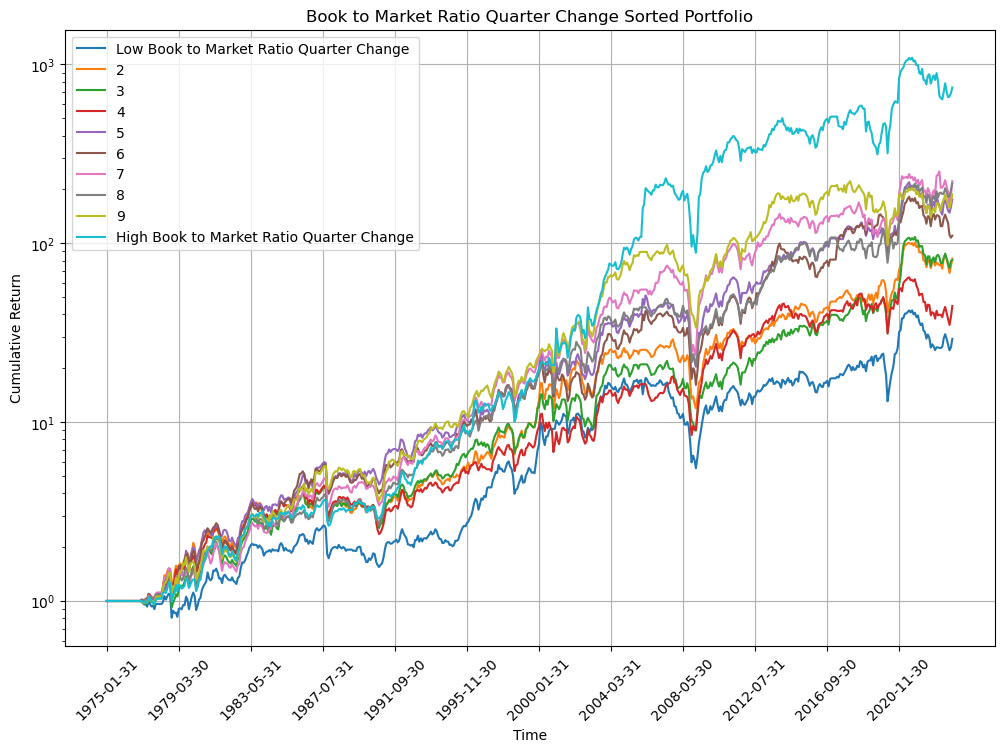

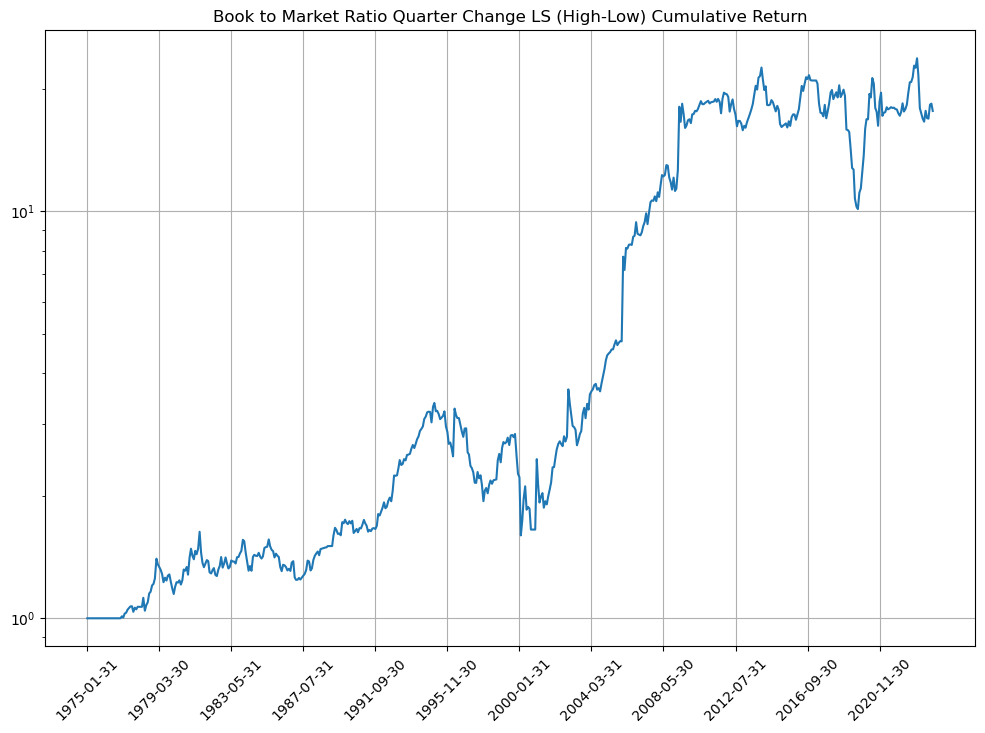

In [50]:
# Construct the ev / ebitda quarterly change
df_sm_pct =  df_sm.diff(3) / df_sm.rolling(window=36, min_periods=8).std()
sm_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_sm_pct * dfs['idx_vol_threshold'],
        holding_period=3,
        quantiles=np.linspace(.1, 1, 9, endpoint=False)
        )
)
plot_group_cum(sm_pct_portfolio, "Book to Market Ratio Quarter Change")
plot_solo_cum(ls(sm_pct_portfolio, -1, 0), "Book to Market Ratio Quarter Change LS (High-Low) Cumulative Return")

# PEG

In [51]:
# Construct the PEG
df_peg = get_peg_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_peg[~idx_Q] = np.nan
df_peg.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,1.796875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,113.906250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


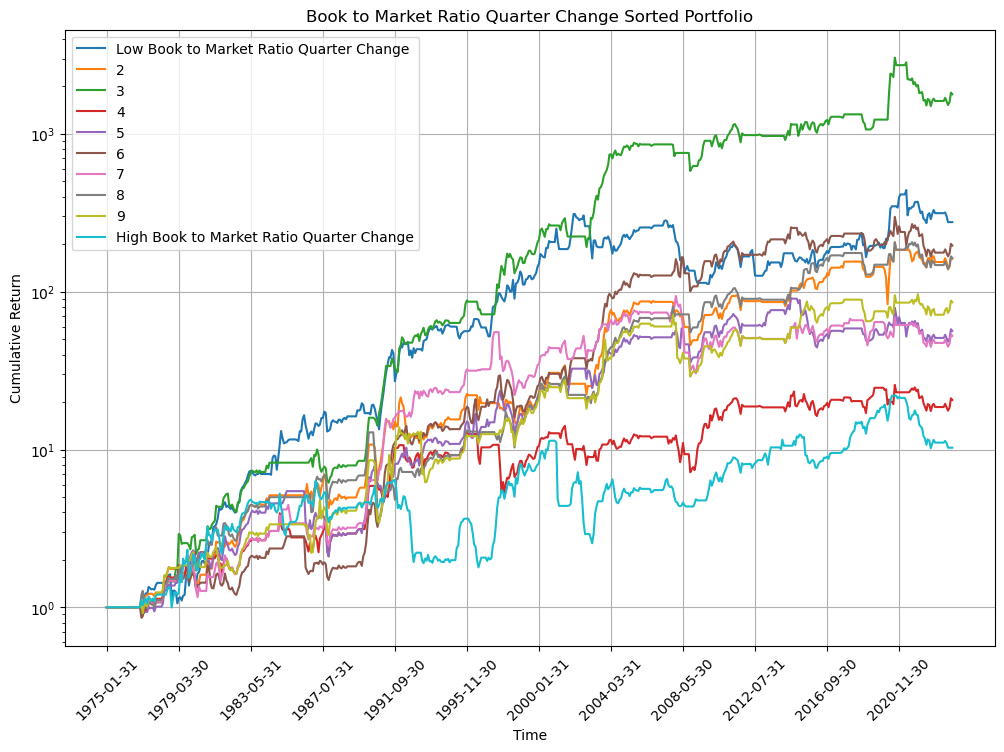

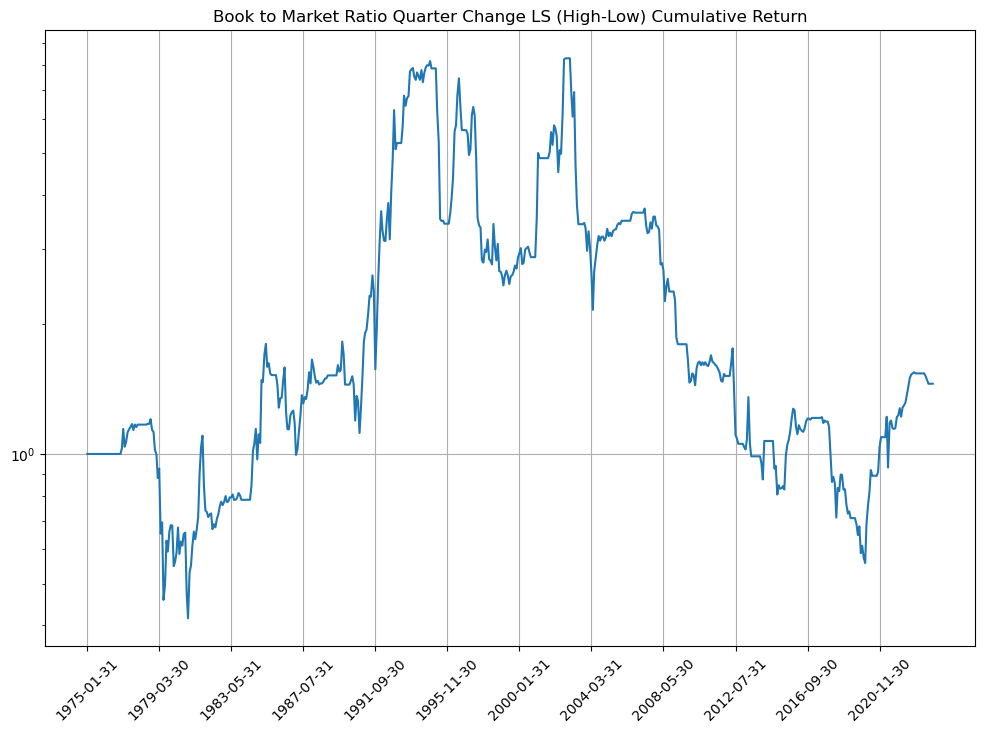

In [52]:
# Construct the peg ratio quarterly change
df_peg_pct =  df_peg.diff(3) / df_peg.rolling(window=36, min_periods=8).std()
peg_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_peg_pct * dfs['idx_vol_threshold'],
        holding_period=3,
        quantiles=np.linspace(.1, 1, 9, endpoint=False)
        )
)
plot_group_cum(peg_pct_portfolio, "Book to Market Ratio Quarter Change")
plot_solo_cum(ls(peg_pct_portfolio, 0, -1), "Book to Market Ratio Quarter Change LS (High-Low) Cumulative Return")